# Task 1: Gradient of Gaussian (GoG) Filtering

## a. Compute continuous GoG-filter kernels for convolution in x- and y-direction

Example: for standard deviation $\sigma = 0.5$, the two 2D kernels are:

$$G_x =
\begin{bmatrix}
\phantom{-}0.0000 & \phantom{-}0.0001 & 0.0000 & -0.0001 & -0.0000 \\
\phantom{-}0.0002 & \phantom{-}0.0466 & 0.0000 & -0.0466 & -0.0002 \\
\phantom{-}0.0017 & \phantom{-}0.3446 & 0.0000 & -0.3446 & -0.0017 \\
\phantom{-}0.0002 & \phantom{-}0.0466 & 0.0000 & -0.0466 & -0.0002 \\
\phantom{-}0.0000 & \phantom{-}0.0001 & 0.0000 & -0.0001 & -0.0000
\end{bmatrix}$$,

$$G_y = G_x^T$$

### Imports and Image Preperation

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [16]:
# Load image (replace with your own if needed)
I = plt.imread("..\\ampelmaennchen.png")

# Convert to grayscale if RGB
if I.ndim == 3:
    I = I.mean(axis=2)

# Convert to double precision and normalize
I = I.astype(np.float64)
I = (I - I.min()) / (I.max() - I.min())

### Visualize Input Image

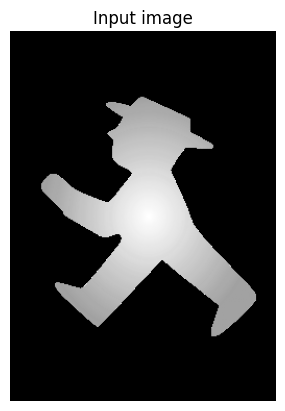

In [17]:
plt.imshow(I, cmap="gray")
plt.title("Input image")
plt.axis("off")
plt.show()

### Kernel Construction Function

In [18]:
def gog_kernels(sigma, size):
    """
    Compute continuous Gradient-of-Gaussian kernels.
    size must be odd.
    """
    k = size // 2
    x, y = np.meshgrid(
        np.arange(-k, k + 1),
        np.arange(-k, k + 1)
    )

    G = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    Gx = -x / (sigma**2) * G
    Gy = -y / (sigma**2) * G

    return Gx, Gy

Example with $σ = 0.5$ and 5x5 kernel

In [19]:
sigma = 0.5
kernel_size = 5

Gx, Gy = gog_kernels(sigma, kernel_size)

print("Gx:\n", np.round(Gx, 4))
print("Gy:\n", np.round(Gy, 4))

Gx:
 [[ 0.000e+00  1.000e-04  0.000e+00 -1.000e-04 -0.000e+00]
 [ 2.000e-04  4.660e-02  0.000e+00 -4.660e-02 -2.000e-04]
 [ 1.700e-03  3.446e-01  0.000e+00 -3.446e-01 -1.700e-03]
 [ 2.000e-04  4.660e-02  0.000e+00 -4.660e-02 -2.000e-04]
 [ 0.000e+00  1.000e-04  0.000e+00 -1.000e-04 -0.000e+00]]
Gy:
 [[ 0.000e+00  2.000e-04  1.700e-03  2.000e-04  0.000e+00]
 [ 1.000e-04  4.660e-02  3.446e-01  4.660e-02  1.000e-04]
 [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00]
 [-1.000e-04 -4.660e-02 -3.446e-01 -4.660e-02 -1.000e-04]
 [-0.000e+00 -2.000e-04 -1.700e-03 -2.000e-04 -0.000e+00]]


## b. Apply these filters to your input image I to derive two gradient images: $𝐼_𝑥$ and $𝐼_𝑦$ (one in $x$- and one in $y$-direction).
Write a function for the convolution of the image with the kernel and ignore the boundaries of the image for simplicity, i.e. no padding needed (you may use builtin convolution functions such as convolve in NumPy or convolve2d in SciPy).

In [20]:
def convolve_valid(image, kernel):
    return signal.convolve2d(image, kernel, mode="valid")

In [21]:
Ix = convolve_valid(I, Gx)
Iy = convolve_valid(I, Gy)



## c. Compute and visualize the gradient magnitude image 𝐺:


### Compute $𝐺 = \sqrt{𝐼^2_𝑥 + 𝐼^2_𝑦}$

In [22]:
Gmag = np.sqrt(Ix**2 + Iy**2)

### Visualization of the Images

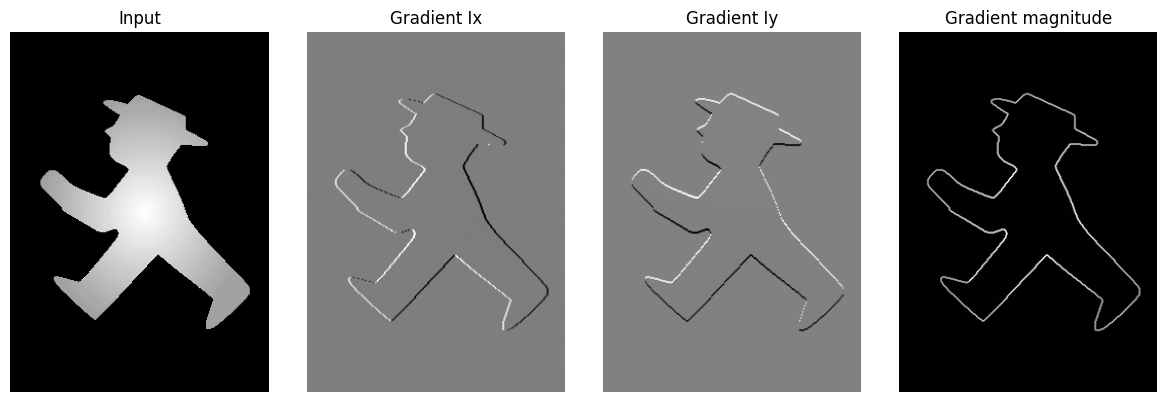

In [23]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(I, cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(Ix, cmap="gray")
plt.title("Gradient Ix")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(Iy, cmap="gray")
plt.title("Gradient Iy")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(Gmag, cmap="gray")
plt.title("Gradient magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()

# Task 2: Förstner interest operator
Use the gradient images to identify Förstner interest points in your input image.

## a. Compute the autocorrelation matrix 𝑀 for each pixel using a moving window 𝑤

Compute the autocorrelation matrix 𝑀 for each pixel using a moving window 𝑤 of 5×5 pixels. Perform convolution based on this window to include the local neighborhood around each pixel (use $I_x$, $I_y$ and ignore the boundaries of the images):




$$𝑀 = w \ast
\begin{bmatrix}
I_x^2 & I_xI_y \\
I_xI_y & I_y^2
\end{bmatrix}$$

In [35]:
def create_sliding_window(size : int):
    w = np.ones((size,size))/(size**2)
    return w

w = create_sliding_window(size=5)

print(w)

[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]


In [65]:
Mxx = signal.convolve2d(w, Ix*Ix)
Mxy = signal.convolve2d(w, Ix*Iy)
Myx = Mxy
Myy = signal.convolve2d(w, Iy*Iy)


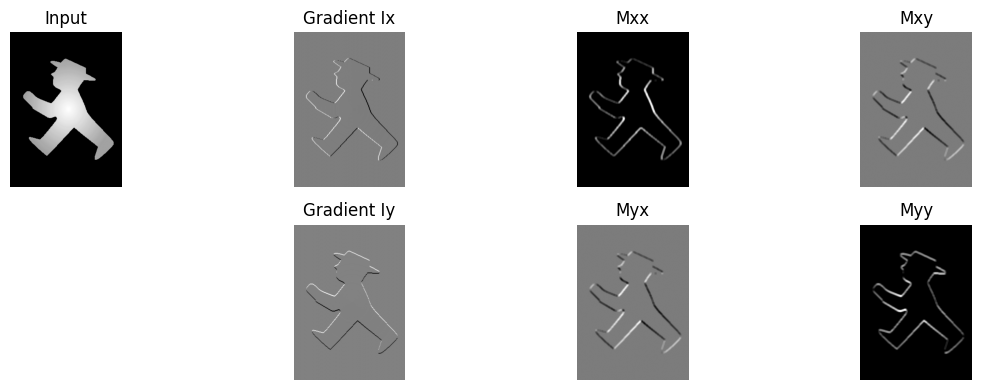

In [74]:
plt.figure(figsize=(12, 4))

plt.subplot(2, 4, 1)
plt.imshow(I, cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(Ix, cmap="gray")
plt.title("Gradient Ix")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(Mxx, cmap="gray")
plt.title("Mxx")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(Mxy, cmap="gray")
plt.title("Mxy")
plt.axis("off")


plt.subplot(2, 4, 6)
plt.imshow(Iy, cmap="gray")
plt.title("Gradient Iy")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(Myx, cmap="gray")
plt.title("Myx")
plt.axis("off")

plt.subplot(2, 4, 8)
plt.imshow(Myy, cmap="gray")
plt.title("Myy")
plt.axis("off")

plt.tight_layout()
plt.show()

## Compute the cornerness W and roundness Q from 𝑀 for each pixel
Compute the cornerness W and roundness Q from 𝑀 for each pixel and store the values in two matrices W and Q.
Plot the values in W and Q with an appropriate colormap (imshow, cmap='jet').

We can either use numpy to create a pixel based image of 2x2 matrices and derive the eigenvalues for each such 2x2 matrix...

In [47]:
(H,W) = I.shape
M = np.zeros((H, W, 2, 2))
M[..., 0, 0] = Mxx
M[..., 0, 1] = Mxy
M[..., 1, 0] = Myx
M[..., 1, 1] = Myy

eigvals = np.linalg.eigvals(M)

Or we can be smarter:

For a 2×2 symmetric matrix, eigenvalues are:
$\lambda_{1,2} = \frac{\text{trace} \pm \sqrt{\text{trace}^2 - 4\det}}{2}$

Which means we can compute the eigenvalues (as well as cornerness and roundedness) directly for all pixels using matrix operations on the different M_ij parts:

trace = Mxx + Myy

and

det = Mxx * Myy - Mxy * Myx

In [86]:
trace = Mxx + Myy
print(np.max(trace))
print(np.min(trace))
# Note that we have a pixel with trace(x,y) = 0.0 here. What to do in case of element wise division for q?

det = Mxx * Myy - Mxy * Myx
print(np.max(det))
print(np.min(det))

lambda1 = (trace + np.sqrt(trace**2 - 4*det))/2
lambda2 = (trace - np.sqrt(trace**2 - 4*det))/2

# Division by zero!? q = 4*np.divide(det, trace**2)
Q = 1-(np.divide(lambda1 - lambda2, lambda1 + lambda2))**2
W = np.divide(np.multiply(lambda1, lambda2), lambda1 + lambda2)

0.08815775298355541
0.0
0.001647349082082141
-2.5849394142282115e-26


C:\Users\mbechman\AppData\Local\Temp\ipykernel_13624\1513879811.py:14: RuntimeWarning: invalid value encountered in divide
  q = 1-(np.divide(lambda1 - lambda2, lambda1 + lambda2))**2
C:\Users\mbechman\AppData\Local\Temp\ipykernel_13624\1513879811.py:15: RuntimeWarning: invalid value encountered in divide
  w = np.divide(np.multiply(lambda1, lambda2), lambda1 + lambda2)


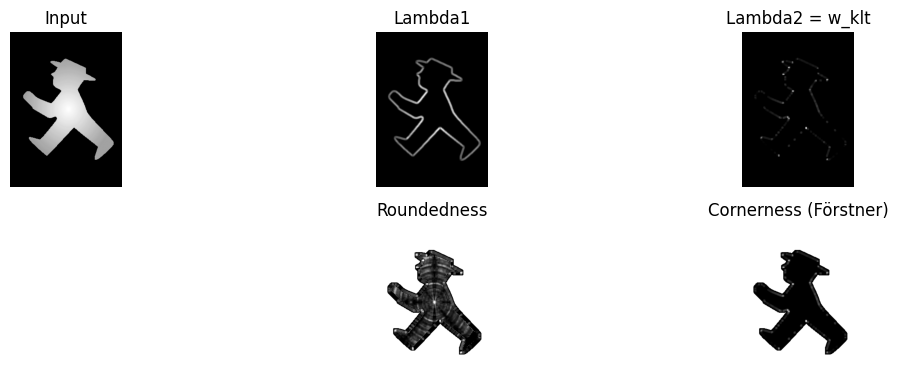

In [88]:
plt.figure(figsize=(12, 4))

plt.subplot(2, 3, 1)
plt.imshow(I, cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(lambda1, cmap="gray")
plt.title("Lambda1")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(lambda2, cmap="gray")
plt.title("Lambda2 = w_klt")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(Q, cmap="gray")
plt.title("Roundedness")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(W, cmap="gray")
plt.title("Cornerness (Förstner)")
plt.axis("off")

plt.tight_layout()


## Derive a binary mask of potential interest points
Derive a binary mask of potential interest points by simultaneously applying the thresholds $t_w = 0.004$  and $t_q = 0.5$ on W and Q, respectively.